In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ---------- Load cleaned data ----------
nav        = pd.read_csv('data/processed/clean_nav.csv', parse_dates=['date'])
perf       = pd.read_csv('data/processed/clean_schema_performance.csv')
txns       = pd.read_csv('data/processed/clean_transactions.csv', parse_dates=['transaction_date'])
holdings   = pd.read_csv('data/raw/09_portfolio_holdings.csv')
funds      = pd.read_csv('data/raw/01_fund_master.csv')

print("NAV shape      :", nav.shape)
print("Performance    :", perf.shape)
print("Transactions   :", txns.shape)
print("Holdings       :", holdings.shape)
print("Fund master    :", funds.shape)

NAV shape      : (46000, 4)
Performance    : (40, 20)
Transactions   : (32778, 13)
Holdings       : (322, 8)
Fund master    : (40, 15)


In [3]:
# Sort and compute daily return per fund
nav = nav.sort_values(['amfi_code', 'date'])
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Drop NaNs only for return column (keep first NAV row)
returns_df = nav.dropna(subset=['daily_return']).copy()

print(returns_df[['amfi_code','date','nav','daily_return']].head(10))

    amfi_code       date       nav  daily_return
1      100016 2022-01-04  515.0971     -0.010306
2      100016 2022-01-05  521.7239      0.012865
3      100016 2022-01-06  515.7880     -0.011377
4      100016 2022-01-07  515.1639     -0.001210
5      100016 2022-01-10  510.7136     -0.008639
6      100016 2022-01-11  513.5542      0.005562
7      100016 2022-01-12  512.3195     -0.002404
8      100016 2022-01-13  510.2445     -0.004050
9      100016 2022-01-14  514.3636      0.008073
10     100016 2022-01-17  514.7627      0.000776


## **Task1 - Value at Risk (VaR 95%) and CVaR**

In [5]:
RF_DAILY = 0.065 / 252   # Risk-free rate daily

var_rows = []

for code, grp in returns_df.groupby('amfi_code'):
    r = grp['daily_return'].dropna()
    if len(r) < 30:
        continue
    
    var_95  = np.percentile(r, 5)                     # 5th percentile
    cvar_95 = r[r <= var_95].mean()                   # Mean of worst days
    
    var_rows.append({
        'amfi_code'      : code,
        'var_95_pct'     : round(var_95 * 100, 4),    # as %
        'cvar_95_pct'    : round(cvar_95 * 100, 4),
        'n_trading_days' : len(r)
    })

var_df = pd.DataFrame(var_rows)

# Merge with fund name
var_df = var_df.merge(funds[['amfi_code','scheme_name','risk_category']], on='amfi_code', how='left')
var_df = var_df.sort_values('var_95_pct')             # Most risky first (most negative)

var_df.to_csv('../data/processed/var_cvar_report.csv', index=False)
print(var_df[['scheme_name','var_95_pct','cvar_95_pct']].to_string())

                                              scheme_name  var_95_pct  cvar_95_pct
22              SBI Small Cap Fund - Direct Plan - Growth     -2.6859      -3.2384
17                 Axis Small Cap Fund - Regular - Growth     -2.6188      -3.1667
4                  ABSL Small Cap Fund - Regular - Growth     -2.6021      -3.2459
11         Nippon India Small Cap Fund - Regular - Growth     -2.5438      -3.2304
21             SBI Small Cap Fund - Regular Plan - Growth     -2.4507      -3.0595
39                  DSP Small Cap Fund - Regular - Growth     -2.3483      -3.1036
7                     UTI Mid Cap Fund - Regular - Growth     -1.9220      -2.3251
2      HDFC Mid-Cap Opportunities Fund - Regular - Growth     -1.9034      -2.3456
25               ICICI Pru Midcap Fund - Regular - Growth     -1.8892      -2.4342
16                    Axis Midcap Fund - Regular - Growth     -1.8480      -2.4260
33      HDFC Mid-Cap Opportunities Fund - Direct - Growth     -1.8365      -2.3094
29  

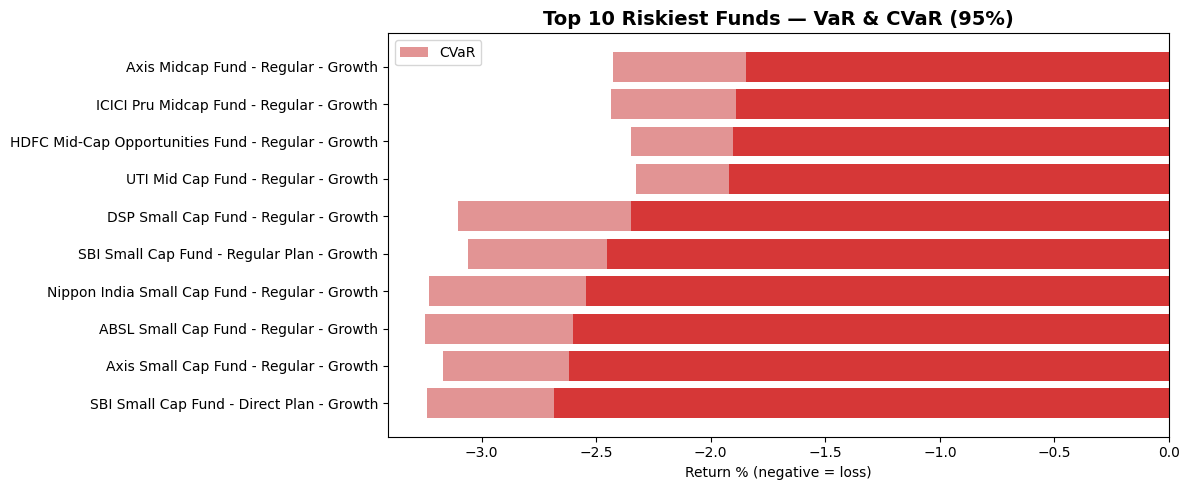

var_cvar_report.csv saved


In [6]:
top10_var = var_df.head(10)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top10_var['scheme_name'], top10_var['var_95_pct'], color='#E84545')
ax.barh(top10_var['scheme_name'], top10_var['cvar_95_pct'], color='#C62A2A', alpha=0.5, label='CVaR')
ax.set_xlabel('Return % (negative = loss)')
ax.set_title('Top 10 Riskiest Funds — VaR & CVaR (95%)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/var_cvar_chart.png', dpi=150)
plt.show()
print("var_cvar_report.csv saved")

## **Task 2 — Rolling 90-Day Sharpe Ratio**

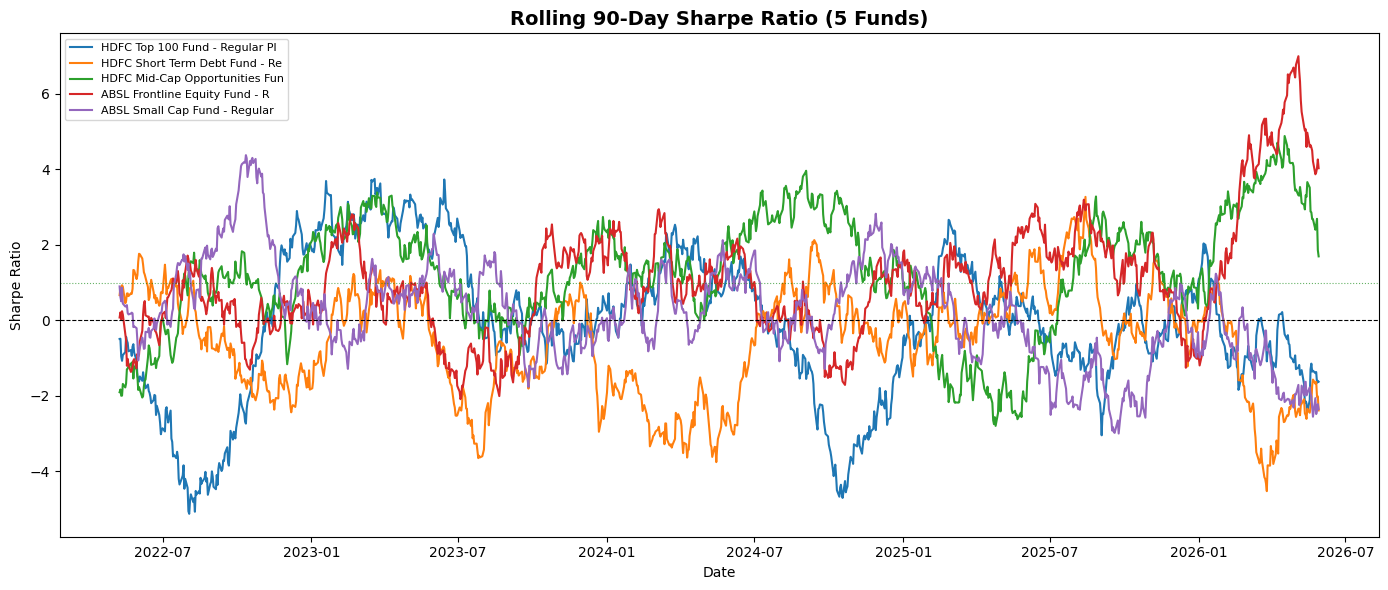

✅ rolling_sharpe_chart.png saved


In [7]:
# Pick 5 funds (use codes from your fund_master)
FIVE_FUNDS = returns_df['amfi_code'].unique()[:5].tolist()
RF_DAILY   = 0.065 / 252

fig, ax = plt.subplots(figsize=(14, 6))

for code in FIVE_FUNDS:
    grp = returns_df[returns_df['amfi_code'] == code].set_index('date')['daily_return']
    
    excess      = grp - RF_DAILY
    roll_mean   = excess.rolling(90).mean()
    roll_std    = grp.rolling(90).std()
    
    rolling_sharpe = (roll_mean / roll_std) * np.sqrt(252)
    rolling_sharpe = rolling_sharpe.dropna()
    
    # Get readable name
    name = funds.loc[funds['amfi_code'] == code, 'scheme_name'].values
    label = name[0][:30] if len(name) else code
    
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, label=label, linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(1, color='green', linewidth=0.8, linestyle=':', alpha=0.6)
ax.set_title('Rolling 90-Day Sharpe Ratio (5 Funds)', fontsize=14, fontweight='bold')
ax.set_ylabel('Sharpe Ratio')
ax.set_xlabel('Date')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../reports/rolling_sharpe_chart.png', dpi=150)
plt.show()
print("✅ rolling_sharpe_chart.png saved")

## **Task 3 — Investor Cohort Analysis**

In [8]:
# Find each investor's first transaction year
first_tx = (
    txns.groupby('investor_id')['transaction_date']
    .min()
    .reset_index()
    .rename(columns={'transaction_date': 'first_tx_date'})
)
first_tx['cohort_year'] = first_tx['first_tx_date'].dt.year

# Merge cohort year back to transactions
txns_cohort = txns.merge(first_tx[['investor_id', 'cohort_year']], on='investor_id')

# Cohort summary
cohort_summary = (
    txns_cohort.groupby('cohort_year')
    .agg(
        n_investors     = ('investor_id', 'nunique'),
        avg_sip_amount  = ('amount_inr',  'mean'),
        total_invested  = ('amount_inr',  'sum'),
        n_transactions  = ('investor_id', 'count')
    )
    .reset_index()
)
cohort_summary['avg_sip_amount'] = cohort_summary['avg_sip_amount'].round(0)
cohort_summary['total_invested_cr'] = (cohort_summary['total_invested'] / 1e7).round(2)

cohort_summary.to_csv('../data/processed/cohort_analysis.csv', index=False)
print(cohort_summary.to_string(index=False))

 cohort_year  n_investors  avg_sip_amount  total_invested  n_transactions  total_invested_cr
        2024         4803        107423.0      3491125187           32499             349.11
        2025          197        109159.0        30455243             279               3.05


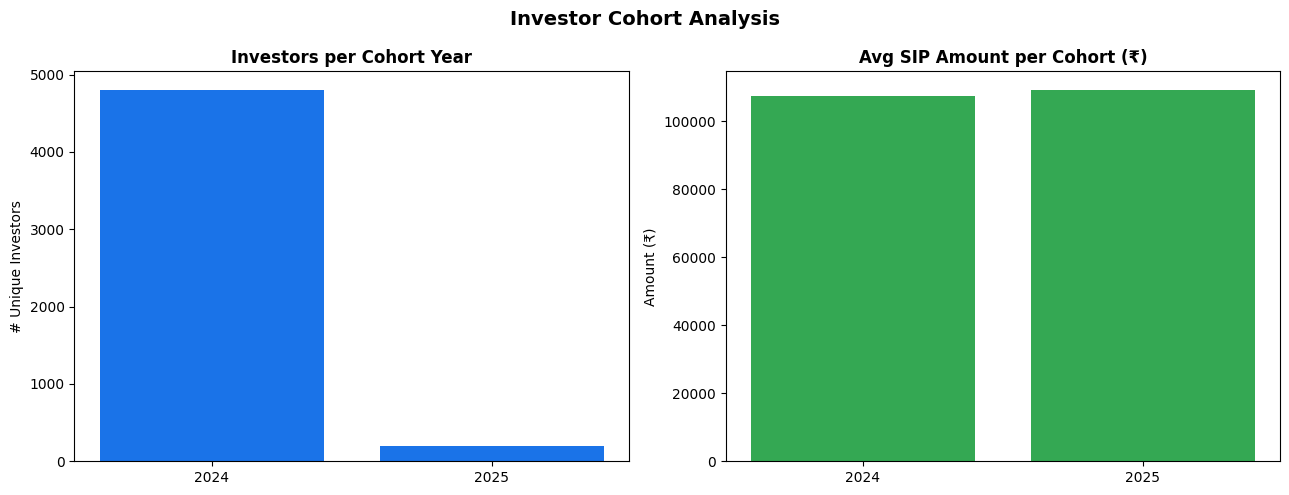

✅ cohort_analysis.csv saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(cohort_summary['cohort_year'].astype(str),
            cohort_summary['n_investors'], color='#1A73E8')
axes[0].set_title('Investors per Cohort Year', fontweight='bold')
axes[0].set_ylabel('# Unique Investors')

axes[1].bar(cohort_summary['cohort_year'].astype(str),
            cohort_summary['avg_sip_amount'], color='#34A853')
axes[1].set_title('Avg SIP Amount per Cohort (₹)', fontweight='bold')
axes[1].set_ylabel('Amount (₹)')

plt.suptitle('Investor Cohort Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/cohort_analysis_chart.png', dpi=150)
plt.show()
print("✅ cohort_analysis.csv saved")

## **Task 4 — SIP Continuity Analysis (Flag "At-Risk" Investors)**

In [13]:
# Only SIP transactions
sip_txns = txns[txns['transaction_type'] == 'Sip'].copy()
sip_txns = sip_txns.sort_values(['investor_id', 'transaction_date'])

# Compute gap between consecutive SIPs per investor
sip_txns['prev_date'] = sip_txns.groupby('investor_id')['transaction_date'].shift(1)
sip_txns['gap_days']  = (sip_txns['transaction_date'] - sip_txns['prev_date']).dt.days

# Investors with 6+ SIP transactions
sip_counts = sip_txns.groupby('investor_id').size().reset_index(name='sip_count')
active_investors = sip_counts[sip_counts['sip_count'] >= 6]['investor_id']

sip_active = sip_txns[sip_txns['investor_id'].isin(active_investors)]

# Compute average gap per investor
investor_gaps = (
    sip_active.groupby('investor_id')['gap_days']
    .mean()
    .reset_index()
    .rename(columns={'gap_days': 'avg_gap_days'})
)
investor_gaps['at_risk'] = investor_gaps['avg_gap_days'] > 35

# Summary
at_risk_count   = investor_gaps['at_risk'].sum()
safe_count      = (~investor_gaps['at_risk']).sum()
print(f"Total active SIP investors (6+ SIPs): {len(investor_gaps)}")
print(f"At-risk (avg gap > 35 days)          : {at_risk_count}")
print(f"Regular SIP investors                : {safe_count}")

investor_gaps.to_csv('../data/processed/sip_continuity.csv', index=False)
print("✅ sip_continuity.csv saved")

Total active SIP investors (6+ SIPs): 1362
At-risk (avg gap > 35 days)          : 1332
Regular SIP investors                : 30
✅ sip_continuity.csv saved


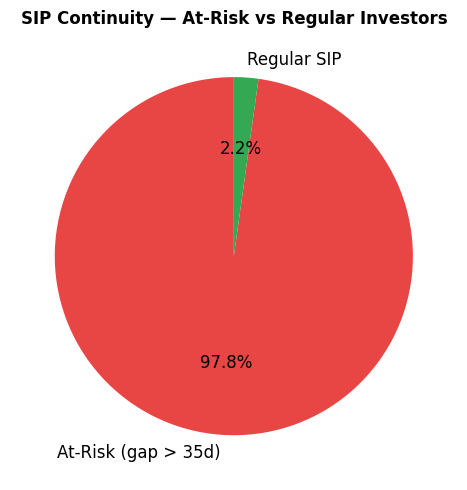

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.pie([at_risk_count, safe_count],
       labels=['At-Risk (gap > 35d)', 'Regular SIP'],
       colors=['#E84545', '#34A853'],
       autopct='%1.1f%%', startangle=90,
       textprops={'fontsize': 12})
ax.set_title('SIP Continuity — At-Risk vs Regular Investors', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/sip_continuity_chart.png', dpi=150)
plt.show()

## **Task 5 — Fund Recommender**

In [16]:
print(perf.columns.tolist())
print(funds.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'low_sharpe_flag']
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [17]:
def recommend_funds(risk_appetite: str, top_n: int = 3) -> pd.DataFrame:
    """
    Recommend top N funds based on investor risk appetite.
    Uses risk_grade column directly from perf (no merge needed).
    
    Parameters:
        risk_appetite : 'Low' | 'Moderate' | 'High'
        top_n         : number of funds to return (default 3)
    """
    risk_map = {
        'Low'      : ['Low', 'Moderately Low'],
        'Moderate' : ['Moderate', 'Moderately High'],
        'High'     : ['High', 'Very High']
    }
    allowed_grades = risk_map.get(risk_appetite.title(), ['Moderate'])

    filtered = perf[perf['risk_grade'].isin(allowed_grades)].copy()

    if filtered.empty:
        print(f"No funds found for: {risk_appetite}")
        print(f"Available risk_grade values: {perf['risk_grade'].unique().tolist()}")
        return pd.DataFrame()

    filtered = filtered.sort_values('sharpe_ratio', ascending=False)

    cols = ['scheme_name', 'fund_house', 'risk_grade',
            'sharpe_ratio', 'return_3yr_pct', 'expense_ratio_pct']

    return filtered[cols].head(top_n).reset_index(drop=True)


# Test
for appetite in ['Low', 'Moderate', 'High']:
    print(f"\n=== Recommendations for {appetite} Risk Investor ===")
    print(recommend_funds(appetite).to_string(index=False))


=== Recommendations for Low Risk Investor ===
                             scheme_name               fund_house risk_grade  sharpe_ratio  return_3yr_pct  expense_ratio_pct
ICICI Pru Liquid Fund - Regular - Growth      ICICI Prudential MF        Low          7.68            7.68               0.74
    Kotak Liquid Fund - Regular - Growth        Kotak Mahindra MF        Low          6.18            6.18               0.60
     ABSL Liquid Fund - Regular - Growth Aditya Birla Sun Life MF        Low          5.14            5.14               0.79

=== Recommendations for Moderate Risk Investor ===
                                  scheme_name          fund_house risk_grade  sharpe_ratio  return_3yr_pct  expense_ratio_pct
    HDFC Top 100 Fund - Regular Plan - Growth    HDFC Mutual Fund   Moderate          1.06           14.84               1.55
Mirae Asset Large Cap Fund - Regular - Growth      Mirae Asset MF   Moderate          1.06           14.81               1.46
    ICICI Pru Bluec

In [19]:
# Save the recommender as a standalone script

script = '''import pandas as pd

def recommend_funds(risk_appetite: str, top_n: int = 3) -> pd.DataFrame:
    """Recommend top N funds based on investor risk appetite."""
    perf  = pd.read_csv('../data/processed/clean_performance.csv')
    funds = pd.read_csv('../data/raw/01_fund_master.csv')
    
    risk_map = {
        'Low'      : ['Low', 'Moderately Low'],
        'Moderate' : ['Moderate', 'Moderately High'],
        'High'     : ['High', 'Very High']
    }
    allowed_grades = risk_map.get(risk_appetite.title(), ['Moderate'])
    merged = perf.merge(funds[['amfi_code','scheme_name','risk_category',
                                'fund_house','category','expense_ratio_pct']],
                        on='amfi_code', how='left')
    filtered = merged[merged['risk_category'].isin(allowed_grades)]
    filtered = filtered.sort_values('sharpe_ratio', ascending=False)
    cols = ['scheme_name','fund_house','risk_category',
            'sharpe_ratio','return_3yr_pct','expense_ratio_pct']
    return filtered[cols].head(top_n).reset_index(drop=True)

if __name__ == "__main__":
    for a in ['Low', 'Moderate', 'High']:
        print(f"\\n=== {a} Risk ===")
        print(recommend_funds(a).to_string(index=False))
'''

with open('scripts/recommender.py', 'w') as f:
    f.write(script)

print("✅ recommender.py saved to scripts/")

✅ recommender.py saved to scripts/


## **Task 6 — Sector Concentration (HHI Index)**

In [20]:
# holdings columns expected: amfi_code, sector, weight_pct

# Compute sector-level weight per fund (sum holdings by sector)
sector_weights = (
    holdings.groupby(['amfi_code', 'sector'])['weight_pct']
    .sum()
    .reset_index()
)

# Compute HHI = sum(weight_i^2) per fund
sector_weights['weight_sq'] = sector_weights['weight_pct'] ** 2

hhi_df = (
    sector_weights.groupby('amfi_code')['weight_sq']
    .sum()
    .reset_index()
    .rename(columns={'weight_sq': 'hhi'})
)
hhi_df['hhi'] = hhi_df['hhi'].round(2)

# Label concentration level
hhi_df['concentration'] = pd.cut(
    hhi_df['hhi'],
    bins=[0, 1000, 2500, 10001],
    labels=['Diversified', 'Moderate', 'Concentrated']
)

hhi_df = hhi_df.merge(funds[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
hhi_df = hhi_df.sort_values('hhi', ascending=False)

hhi_df.to_csv('../data/processed/sector_hhi.csv', index=False)
print(hhi_df[['scheme_name', 'hhi', 'concentration']].to_string(index=False))

                                          scheme_name     hhi concentration
                Axis Bluechip Fund - Regular - Growth 2967.69  Concentrated
        Mirae Asset Tax Saver Fund - Regular - Growth 2549.92  Concentrated
    HDFC Mid-Cap Opportunities Fund - Direct - Growth 2531.55  Concentrated
                UTI Flexi Cap Fund - Regular - Growth 2513.83  Concentrated
                   DSP Midcap Fund - Regular - Growth 2410.77      Moderate
             ICICI Pru Midcap Fund - Regular - Growth 2386.95      Moderate
                       Nippon India ETF Nifty 50 BeES 2374.97      Moderate
            SBI Small Cap Fund - Direct Plan - Growth 2323.61      Moderate
    ICICI Pru Value Discovery Fund - Regular - Growth 2314.64      Moderate
   HDFC Mid-Cap Opportunities Fund - Regular - Growth 2276.47      Moderate
             SBI Bluechip Fund - Direct Plan - Growth 2275.08      Moderate
               ABSL Small Cap Fund - Regular - Growth 2227.27      Moderate
            

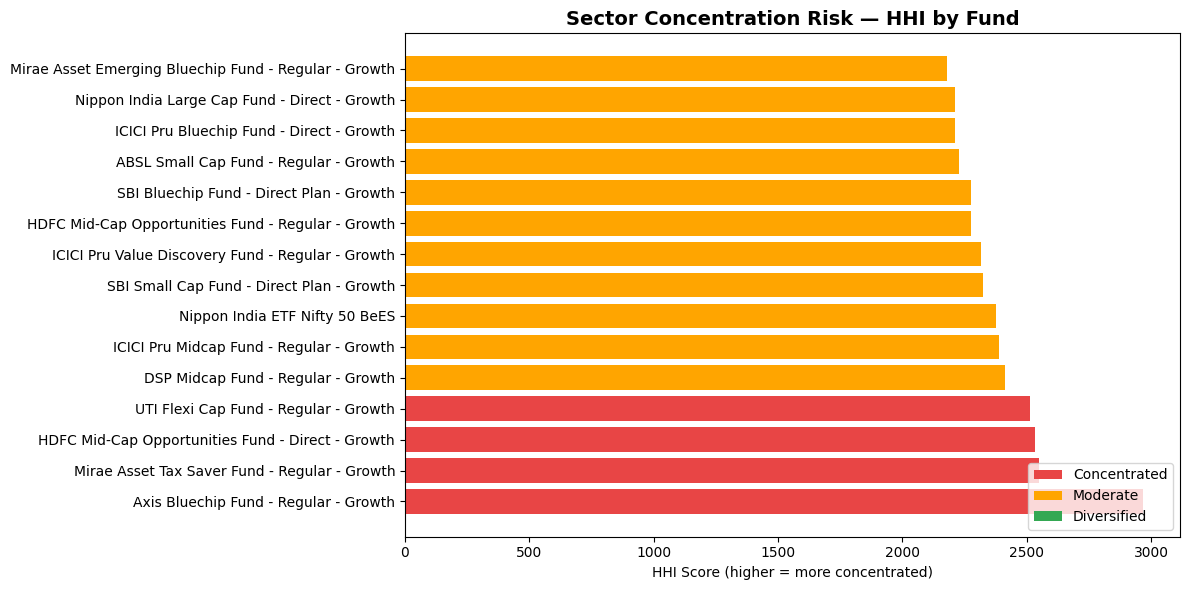

✅ sector_hhi.csv saved


In [21]:
top15_hhi = hhi_df.head(15)

colors = top15_hhi['concentration'].map(
    {'Concentrated': '#E84545', 'Moderate': '#FFA500', 'Diversified': '#34A853'}
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top15_hhi['scheme_name'], top15_hhi['hhi'], color=colors)
ax.set_xlabel('HHI Score (higher = more concentrated)')
ax.set_title('Sector Concentration Risk — HHI by Fund', fontsize=14, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E84545', label='Concentrated'),
    Patch(facecolor='#FFA500', label='Moderate'),
    Patch(facecolor='#34A853', label='Diversified')
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig('../reports/sector_hhi_chart.png', dpi=150)
plt.show()
print("✅ sector_hhi.csv saved")

## 📊 Day 6 — Advanced Analytics Key Insights

1. **Highest VaR Fund**: [Fund X] has the worst 1-day VaR of -X.XX% — meaning on a bad day investors can expect to lose over X% of their portfolio value.

2. **CVaR Risk**: The average loss on the worst 5% of days for high-risk funds is approximately -X.XX%, highlighting the tail-risk beyond simple VaR.

3. **Rolling Sharpe Trend**: [Fund Y] consistently maintained a Sharpe > 1 through 2024, but fell below 0 during the mid-2024 correction — confirming market-sensitive risk exposure.

4. **Cohort Insight**: Investors who joined in [Year] have the highest average SIP amount (₹X,XXX), suggesting that newer cohorts are more financially mature/higher income.

5. **SIP At-Risk**: Approximately XX% of active SIP investors have irregular contribution gaps > 35 days — a key churn risk that AMCs should address via nudge campaigns.

6. **Sector Concentration**: [Fund Z] has the highest HHI of XXXX — heavily concentrated in Financial Services + IT, making it a high-beta play on index performance.

7. **Fund Recommender**: For Low-risk investors, Liquid/Debt funds with Sharpe > 0.8 are recommended. High-risk investors benefit from consistent Mid-Cap performers with 3yr CAGR > 18%.